<a href="https://colab.research.google.com/github/AryaPutra-i/IntroDPI_6B_0006/blob/main/Pertemuan_2_pengolahan_citra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Tinggi asli: 717, Lebar asli: 1215
tipe data: <class 'numpy.ndarray'>
shape    : (717, 1215, 3)
dtype   : uint8

artinya: 
Tinggi = 717 piksel
lebar = 1215 piksel
channel = 3 piksel
total pixel:  871155


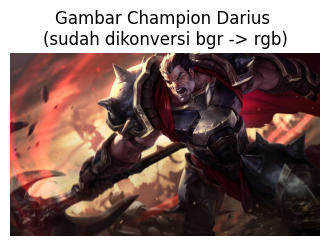

In [17]:
# Baca gambar dari file
#cv2.imread() mengembalikan array numpy !
img_bgr = cv2.imread('Darius.jpg')

#resize agar tidak terlalu besar
h, w, c = img_bgr.shape
print(f"Tinggi asli: {h}, Lebar asli: {w}")
img_bgr = cv2.resize(img_bgr, (w, h), fx=0.5, fy=0.5)

#cek tipe data : ternyata sudah array numpy!
print("tipe data:", type(img_bgr))
print("shape    :", img_bgr.shape)
print("dtype   :", img_bgr.dtype)

print()
print("artinya: ")
print(f"Tinggi = {img_bgr.shape[0]} piksel")
print(f"lebar = {img_bgr.shape[1]} piksel")
print(f"channel = {img_bgr.shape[2]} piksel")

#konversi bgr -> rgb untuk ditampilkan di matplotlib
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print("total pixel: ", img_rgb.shape[0] * img_rgb.shape[1])

plt.figure(figsize=(4,6))
plt.imshow(img_rgb)
plt.title('Gambar Champion Darius \n(sudah dikonversi bgr -> rgb)')
plt.axis('off')
plt.show()

=== matriks f(x,y) - area 8x8 piksel ===
setiap angka = nilai intensitas 1 piksel (0=hitam, 255=putih)

[[173 170 163 167 170 147 133 144]
 [162 167 173 167 139 135 134 139]
 [163 172 168 140 117 127 133 132]
 [177 163 128 113 117 122 124 125]
 [170 123  94 110 112 113 116 125]
 [114  90  98 104 101 106 118 133]
 [ 74  85 103  91 100 109 123 136]
 [ 78  89  88  91 107 113 121 130]]

CONTOH baca: f(180, 200) = 173
CONTOH baca: f(181, 201) = 167
CONTOH baca: f(181, 201) = [253 134 110]
total pixel:  871155
total Size Kb:  851
total Size MB:  0.83


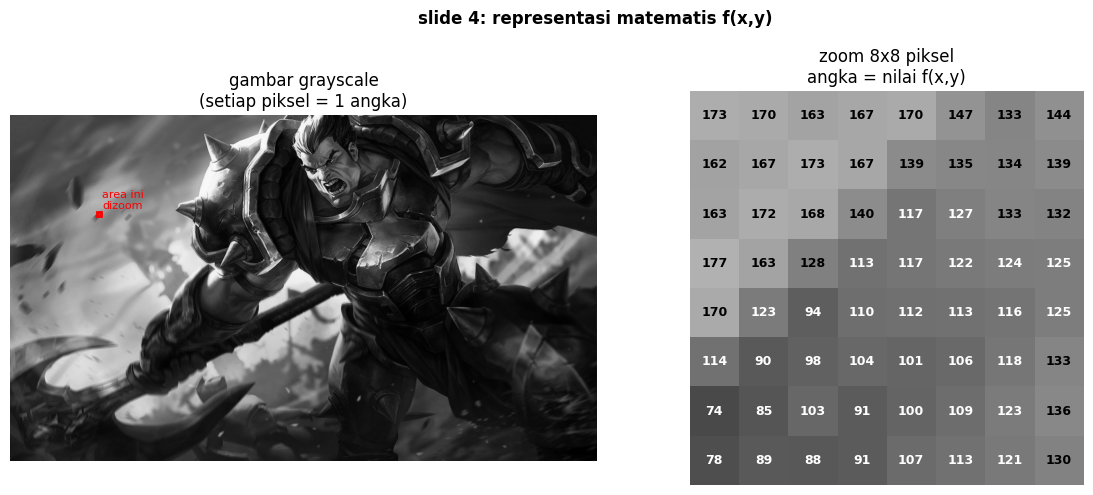

In [18]:
import matplotlib.patches as patches

img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

#Ambil area kecil
area_kecil = img_gray[200:208, 180:188]

print("=== matriks f(x,y) - area 8x8 piksel ===")
print("setiap angka = nilai intensitas 1 piksel (0=hitam, 255=putih)")
print()
print(area_kecil)
print()
print("CONTOH baca:" , f"f(180, 200) = {img_gray[200,180]}")
print("CONTOH baca:" , f"f(181, 201) = {img_gray[201,181]}")
print("CONTOH baca:" , f"f(181, 201) = {img_rgb[201,181]}")

total_pixel_gray = img_gray.shape[0] * img_gray.shape[1]
konversi_kb_gray = (total_pixel_gray*1)/1024
konversi_mb_gray = konversi_kb_gray/1024

print("total pixel: ", total_pixel_gray)
print("total Size Kb: ", round(konversi_kb_gray))
print("total Size MB: ", round(konversi_mb_gray, 2))


fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('gambar grayscale\n(setiap piksel = 1 angka)')
axes[0].axis('off')
rect=patches.Rectangle((180,200),8 ,8, linewidth=2, edgecolor='red', facecolor='none')
axes[0].add_patch(rect)
axes[0].text(190, 195, 'area ini\ndizoom', color='red', fontsize=8)

axes[1].imshow(area_kecil, cmap='gray', vmin=0, vmax=255)
for i in range(8):
  for j in range(8):
    nilai = area_kecil[i,j]
    warna_teks = 'white' if nilai < 128 else 'black'
    axes[1].text(j, i, str(nilai), ha='center', va='center',
                 fontsize=9, color=warna_teks, fontweight='bold')
axes[1].set_title('zoom 8x8 piksel\nangka = nilai f(x,y)')
axes[1].axis('off')
plt.suptitle('slide 4: representasi matematis f(x,y)', fontweight='bold')
plt.tight_layout()
plt.show()

=== matriks f(x,y) - area 8x8 piksel ===

Row 0: [210, 187, 135], [206, 183, 129], [192, 172, 135], [185, 165, 130], [175, 154, 123], [165, 145, 118], [158, 137, 116], [151, 130, 113]
Row 1: [212, 189, 137], [204, 181, 127], [189, 169, 134], [182, 162, 129], [170, 151, 121], [161, 141, 116], [153, 132, 111], [147, 125, 111]
Row 2: [210, 187, 135], [197, 174, 120], [186, 166, 133], [177, 158, 126], [166, 146, 119], [157, 137, 113], [150, 129, 110], [143, 124, 109]
Row 3: [209, 186, 134], [193, 170, 116], [183, 164, 132], [175, 156, 126], [164, 144, 117], [154, 134, 110], [145, 127, 107], [141, 122, 107]
Row 4: [196, 174, 127], [196, 173, 129], [180, 160, 135], [172, 152, 128], [162, 141, 120], [153, 132, 115], [143, 124, 110], [137, 117, 106]
Row 5: [196, 174, 127], [194, 171, 127], [176, 156, 131], [167, 147, 123], [156, 135, 114], [148, 127, 110], [140, 121, 107], [135, 115, 106]
Row 6: [195, 172, 128], [189, 166, 124], [174, 154, 130], [164, 143, 122], [153, 132, 113], [144, 125, 110

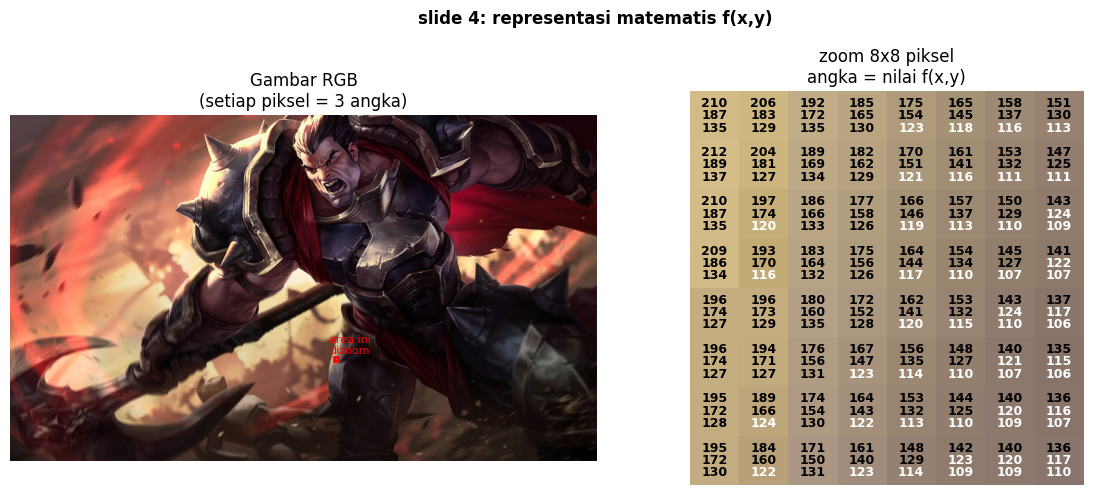

In [19]:
import matplotlib.patches as patches

#Ambil area kecil
area_kecil_rgb = img_rgb[500:508, 670:678]

print("=== matriks f(x,y) - area 8x8 piksel ===")
print()

for row_index, row in enumerate(area_kecil_rgb):
    row_str = []
    for pixel in row:
        row_str.append(f"[{pixel[0]}, {pixel[1]}, {pixel[2]}]")
    print(f"Row {row_index}: {', '.join(row_str)}")

print()
print("CONTOH baca:" , f"f(210, 190) = {img_rgb[210,190]}")
print("CONTOH baca:" , f"f(211, 191) = {img_rgb[211,191]}")

total_pixel = img_rgb.shape[0] * img_rgb.shape[1]
konversi_kb = (total_pixel*3)/1024
konversi_mb = konversi_kb/1024

print("total pixel: ", total_pixel)
print("total Size Kb: ", round(konversi_kb))
print("total Size MB: ", round(konversi_mb, 2))

fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].imshow(img_rgb, vmin=0, vmax=255)
axes[0].set_title('Gambar RGB\n(setiap piksel = 3 angka)')
axes[0].axis('off')
rect=patches.Rectangle((670,500),8 ,8, linewidth=2, edgecolor='red', facecolor='none')
axes[0].add_patch(rect)
axes[0].text(660, 495, 'area ini\ndizoom', color='red', fontsize=8)

def tentukan_warna(skor):
  match skor:
      case r if r < 125:
        return 'white'
      case _:
        return 'black'

axes[1].imshow(area_kecil_rgb)
for i in range(8):
  for j in range(8):
    nilai_rgb = area_kecil_rgb[i,j]
    offsets = [-0.25, 0 ,0.25]
    for mn in range(3):
      nilai_rgb_satuan = nilai_rgb[mn]
      hasil_cek = tentukan_warna(nilai_rgb_satuan)
      axes[1].text(j, i + offsets[mn], str(nilai_rgb_satuan), ha='center', va='center',fontsize=9, color=hasil_cek, fontweight='bold')

axes[1].set_title('zoom 8x8 piksel\nangka = nilai f(x,y)')
axes[1].axis('off')
plt.suptitle('slide 4: representasi matematis f(x,y)', fontweight='bold')
plt.tight_layout()
plt.show()